In [8]:
%matplotlib inline

In [2]:
from seq2seq_eval import *

### one-hot-encoding

In [3]:
lang = lang_voc("eng")

lang.add_sentence("the cat is on the table")
lang.add_sentence("i like pizza")
lang.add_sentence("the pizza is on the table")
lang.add_sentence("the cat likes pizza")


print("word to index: \t", lang.w_to_idx)
print("index to word: \t", lang.idx_to_w)
print("number of words:", lang.n_words)

word to index: 	 {'<UNK>': 2, 'the': 3, 'cat': 4, 'is': 5, 'on': 6, 'table': 7, 'i': 8, 'like': 9, 'pizza': 10, 'likes': 11}
index to word: 	 {0: 'SOS', 1: 'EOS', 2: '<UNK>', 3: 'the', 4: 'cat', 5: 'is', 6: 'on', 7: 'table', 8: 'i', 9: 'like', 10: 'pizza', 11: 'likes'}
number of words: 12


In [4]:
def one_hot_word(word, lang):
    vector = torch.zeros(lang.n_words)
    index = lang.w_to_idx[word]
    vector[index] = 1
    return vector

print(one_hot_word("pizza", lang))

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])


In [5]:
def one_hot_sentence(sentence, lang):
    vectors = []
    for word in sentence.split(' '):
        v = torch.zeros(lang.n_words)
        v[lang.w_to_idx[word]] = 1
        vectors.append(v)
    return torch.stack(vectors)

encoded = one_hot_sentence("the cat likes pizza", lang)
print("encoded sentence: \n", encoded, "\n")
print("shape:", encoded.shape)

encoded sentence: 
 tensor([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]]) 

shape: torch.Size([4, 12])


In [6]:
for word in lang.w_to_idx:
    idx = lang.w_to_idx[word]
    count = lang.w_to_count[word]
    print(f"'{word}' | index={idx} | count={count}")

'<UNK>' | index=2 | count=0
'the' | index=3 | count=5
'cat' | index=4 | count=2
'is' | index=5 | count=2
'on' | index=6 | count=2
'table' | index=7 | count=2
'i' | index=8 | count=1
'like' | index=9 | count=1
'pizza' | index=10 | count=3
'likes' | index=11 | count=1


### normalize string

In [7]:
text = "Héllo!!!   How’s it going? 😊"
normalizer = Normalizer()
normalized = normalizer.normalize_w(text)
print("Normalized: ", normalized)

Normalized:  héllo ! ! ! how s it going ?


### sentence to tensor

In [8]:
tensor = phrase_to_tensor(lang, "i like pizza")

print("Original sentence:", "i like pizza")
print("Tensor:", tensor)
print("Tensor shape:", tensor.shape)

Original sentence: i like pizza
Tensor: tensor([[ 8,  9, 10,  1]])
Tensor shape: torch.Size([1, 4])


### embedding

In [9]:
embedding = nn.Embedding(lang.n_words, 32)(tensor)
print("Embedding shape:", embedding.shape)

Embedding shape: torch.Size([1, 4, 32])


## eng-span

In [11]:
max_input_length = 5
how_many_marges = 6000

In [8]:
input_lang, output_lang, train_loader, val_loader, max_len = \
    get_train_val_dataloaders(batch_size=32,
                              lang1='eng', lang2='span',
                              max_length=max_input_length, valid_ratio=0.1,
                              num_merges=(how_many_marges, 'sp'))

118964 sentence pairs readed
reduced to 7256 sentence pairs
eng 2236
span 4083
eng vocab size after SentencePiece: 6000
span vocab size after SentencePiece: 6000


In [ ]:
hidden_size = 256

encoder = rnn_encoder(input_lang.n_words, hidden_size).to(device)
decoder = rnn_att_decoder(hidden_size, output_lang.n_words,
                          max_length=input_lang.max_len, n_heads=4, n_layers=2).to(device)

0 m 32 sec remaining: 10 m 19 sec (1 5%) train: 2.3720 val: 1.9045
1 m 2 sec remaining: 9 m 19 sec (2 10%) train: 1.7042 val: 1.6856
1 m 35 sec remaining: 9 m 0 sec (3 15%) train: 1.4301 val: 1.5850
2 m 5 sec remaining: 8 m 21 sec (4 20%) train: 1.2108 val: 1.5338
2 m 38 sec remaining: 7 m 54 sec (5 25%) train: 1.0218 val: 1.4933
3 m 8 sec remaining: 7 m 20 sec (6 30%) train: 0.8625 val: 1.4851
3 m 41 sec remaining: 6 m 50 sec (7 35%) train: 0.7205 val: 1.4503
4 m 11 sec remaining: 6 m 17 sec (8 40%) train: 0.5889 val: 1.4425
4 m 41 sec remaining: 5 m 44 sec (9 45%) train: 0.4798 val: 1.4517
5 m 12 sec remaining: 5 m 12 sec (10 50%) train: 0.3929 val: 1.4649
5 m 43 sec remaining: 4 m 40 sec (11 55%) train: 0.3137 val: 1.4694
6 m 13 sec remaining: 4 m 9 sec (12 60%) train: 0.2583 val: 1.4815
6 m 44 sec remaining: 3 m 37 sec (13 65%) train: 0.2136 val: 1.5050
7 m 18 sec remaining: 3 m 7 sec (14 70%) train: 0.1802 val: 1.5025
7 m 50 sec remaining: 2 m 36 sec (15 75%) train: 0.1612 val: 1.

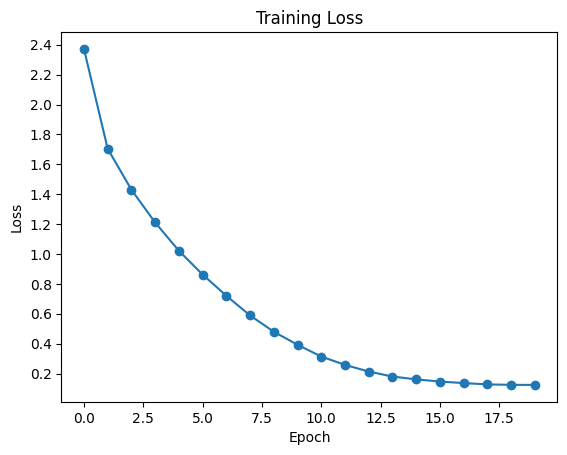

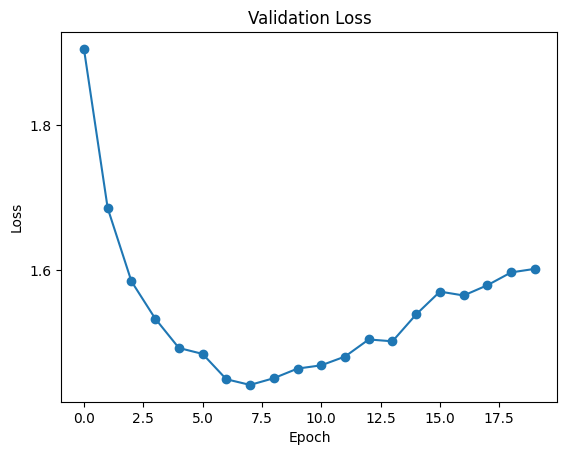

In [33]:
# Train with validation
train(train_loader, encoder, decoder,
      n_epochs=20, print_step=1, plot_step=1, valid_dataloader=val_loader)

input = come in .
output = entra .


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:774: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:775: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


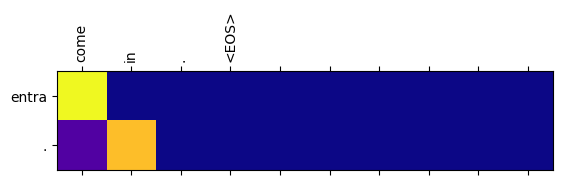

In [59]:
evaluate_and_show_attention("come in .", encoder, decoder, input_lang, output_lang)

input = get out .
output = salí .


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:774: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:775: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


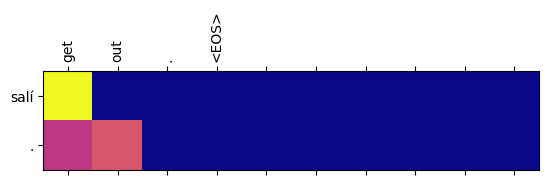

In [68]:
evaluate_and_show_attention("get out .", encoder, decoder, input_lang, output_lang)

input = i run .
output = corría .


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:774: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:775: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


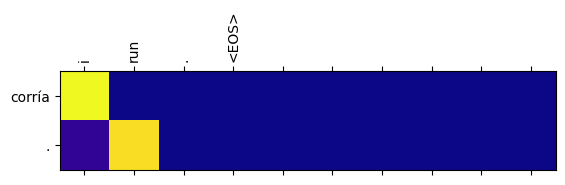

In [50]:
evaluate_and_show_attention("i run .", encoder, decoder, input_lang, output_lang)

In [ ]:
evaluate_and_show_attention("hi .", encoder, decoder, input_lang, output_lang)

input = hi i run .
output = entiendo .


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:774: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:775: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


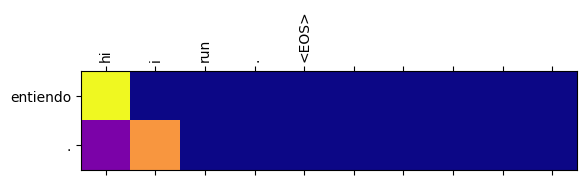

In [78]:
evaluate_and_show_attention("hi i run .", encoder, decoder, input_lang, output_lang)

input = is tom out ?
output = está fuera tom ?


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:774: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:775: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


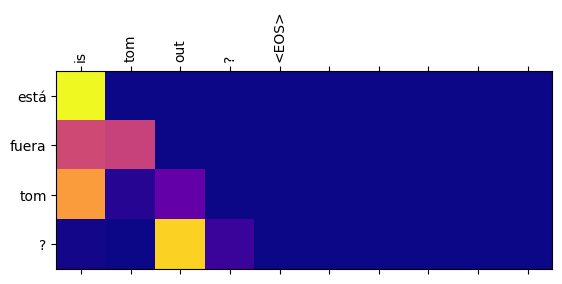

In [69]:
evaluate_and_show_attention("is tom out ?", encoder, decoder, input_lang, output_lang)

input = is tom stayed here ?
output = tom es ?


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:774: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:775: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


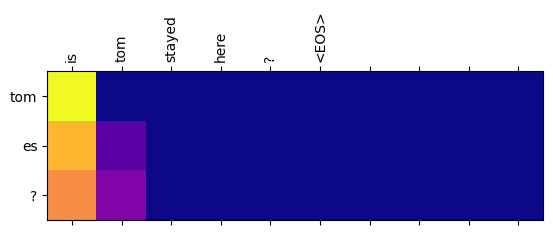

In [71]:
evaluate_and_show_attention("is tom stayed here ?", encoder, decoder, input_lang, output_lang)

input = is tom stayed here
output = tom es puntual .


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:774: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:775: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


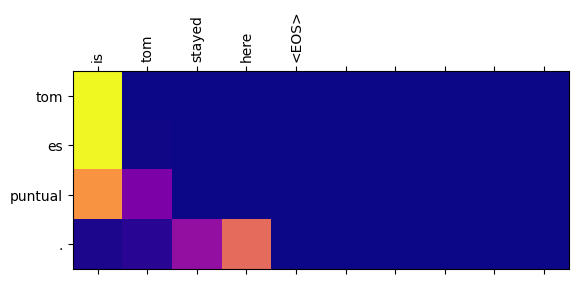

In [86]:
evaluate_and_show_attention("is tom stayed here", encoder, decoder, input_lang, output_lang)

input = is tom sick ?
output = está enfermo ?


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:774: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:775: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


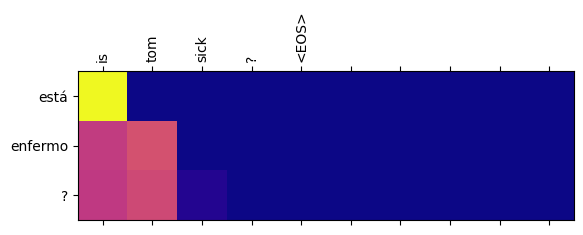

In [72]:
evaluate_and_show_attention("is tom sick ?", encoder, decoder, input_lang, output_lang)

input = is tom smiling ?
output = tom está interesado ?


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:774: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:775: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


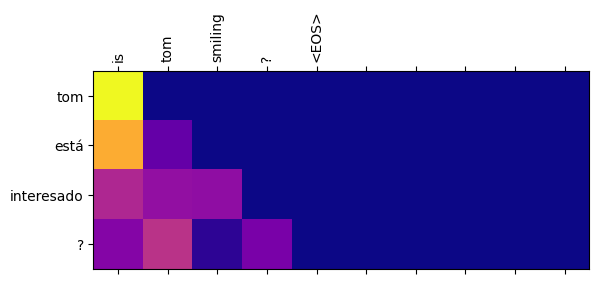

In [75]:
evaluate_and_show_attention("is tom smiling ?", encoder, decoder, input_lang, output_lang)

input = is smiling ?
output = son está ?


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:774: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:775: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


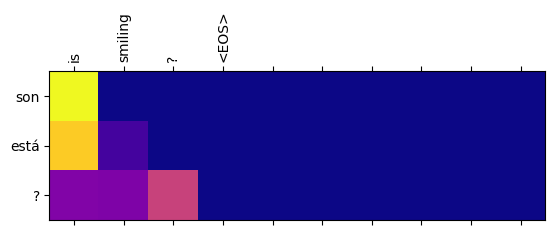

In [74]:
evaluate_and_show_attention("is smiling ?", encoder, decoder, input_lang, output_lang)

In [ ]:
print("Encoder parameters:")
for name, param in encoder.named_parameters():
    print(name, param.numel())

print("\nDecoder parameters:")
for name, param in decoder.named_parameters():
    print(name, param.numel())

encoder_params = sum(p.numel() for p in encoder.parameters())
decoder_params = sum(p.numel() for p in decoder.parameters())

print("\nEncoder parameters:", encoder_params)
print("Decoder parameters:", decoder_params)
print("Total parameters:", encoder_params + decoder_params)

Encoder parameters:
embedding.weight 512000
gru.W_ih 196608
gru.W_hh 196608
gru.b_ih 768
gru.b_hh 768

Decoder parameters:
embedding.weight 512000
W_Q.weight 65536
W_K.weight 65536
W_V.weight 65536
W_O.weight 65536
gru_layers.0.W_ih 393216
gru_layers.0.W_hh 196608
gru_layers.0.b_ih 768
gru_layers.0.b_hh 768
gru_layers.1.W_ih 196608
gru_layers.1.W_hh 196608
gru_layers.1.b_ih 768
gru_layers.1.b_hh 768
out.weight 512000
out.bias 2000

Encoder parameters: 906752
Decoder parameters: 2274256
Total parameters: 3181008


In [ ]:
import os

def save_models(encoder, decoder, save_dir="checkpoints"):
    os.makedirs(save_dir, exist_ok=True)

    torch.save(encoder.state_dict(), os.path.join(save_dir, "encoder_1.pt"))
    torch.save(decoder.state_dict(), os.path.join(save_dir, "decoder_1.pt"))

    print(f"Models saved to {save_dir}/")

save_models(encoder, decoder)

In [16]:
max_input_length = 5
how_many_marges = 8261 # maximum number of merges generation 

In [17]:
input_lang, output_lang, train_loader, val_loader, max_len = \
    get_train_val_dataloaders(batch_size=32,
                              lang1='eng', lang2='span',
                              max_length=max_input_length, valid_ratio=0.1,
                              num_merges=(how_many_marges, 'sp'))

118964 sentence pairs readed
reduced to 7256 sentence pairs
eng 2236
span 4083
eng vocab size after SentencePiece: 8261
span vocab size after SentencePiece: 8261


In [18]:
hidden_size = 256

encoder = rnn_encoder(input_lang.n_words, hidden_size).to(device)
decoder = rnn_att_decoder(hidden_size, output_lang.n_words,
                          max_length=input_lang.max_len, n_heads=4, n_layers=2).to(device)

0 m 28 sec remaining: 9 m 7 sec (1 5%) train: 3.1030 val: 2.4723
0 m 56 sec remaining: 8 m 28 sec (2 10%) train: 2.1193 val: 2.2168
1 m 28 sec remaining: 8 m 24 sec (3 15%) train: 1.7128 val: 2.0942
1 m 58 sec remaining: 7 m 54 sec (4 20%) train: 1.3981 val: 1.9955
2 m 32 sec remaining: 7 m 36 sec (5 25%) train: 1.1287 val: 1.9444
2 m 55 sec remaining: 6 m 50 sec (6 30%) train: 0.9014 val: 1.9094
3 m 19 sec remaining: 6 m 10 sec (7 35%) train: 0.7118 val: 1.8668
3 m 43 sec remaining: 5 m 34 sec (8 40%) train: 0.5532 val: 1.8735
4 m 8 sec remaining: 5 m 3 sec (9 45%) train: 0.4279 val: 1.8811
4 m 33 sec remaining: 4 m 33 sec (10 50%) train: 0.3379 val: 1.8870
4 m 59 sec remaining: 4 m 5 sec (11 55%) train: 0.2766 val: 1.9029
5 m 25 sec remaining: 3 m 36 sec (12 60%) train: 0.2385 val: 1.9062
5 m 52 sec remaining: 3 m 9 sec (13 65%) train: 0.2143 val: 1.9432
6 m 20 sec remaining: 2 m 42 sec (14 70%) train: 0.1984 val: 1.9580
6 m 45 sec remaining: 2 m 15 sec (15 75%) train: 0.1909 val: 1.

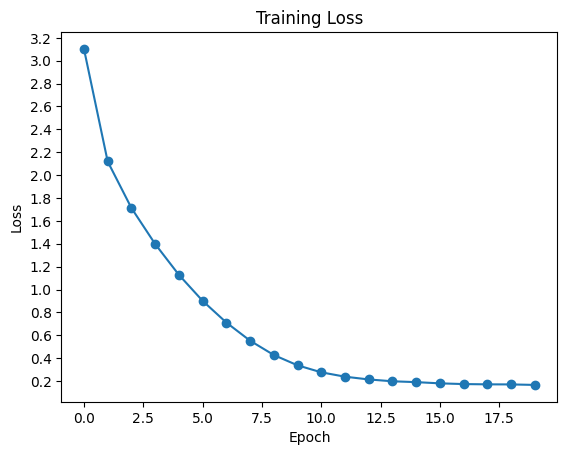

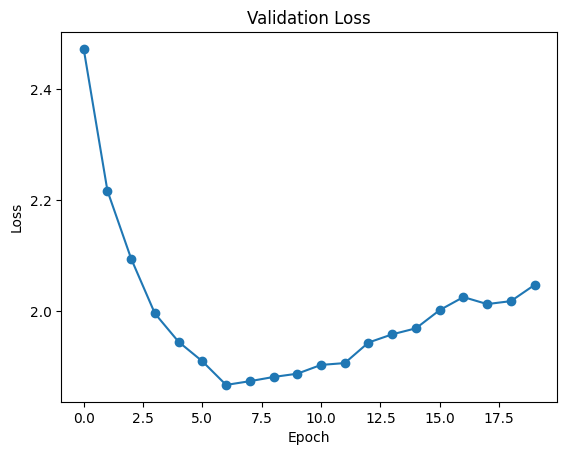

In [19]:
# Train with validation
train(train_loader, encoder, decoder,
      n_epochs=20, print_step=1, plot_step=1, valid_dataloader=val_loader)

In [23]:
import os

def save_models(encoder, decoder, save_dir="checkpoints"):
    os.makedirs(save_dir, exist_ok=True)

    torch.save(encoder.state_dict(), os.path.join(save_dir, "encoder_2.pt"))
    torch.save(decoder.state_dict(), os.path.join(save_dir, "decoder_2.pt"))

    print(f"Models saved to {save_dir}/")

save_models(encoder, decoder)

Models saved to checkpoints/


input = is tom sick ?
output = está tom ?


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:762: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:763: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


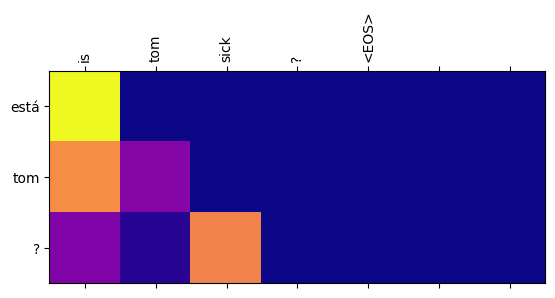

In [22]:
evaluate_and_show_attention("is tom sick ?", encoder, decoder, input_lang, output_lang)

118964 sentence pairs readed
reduced to 7256 sentence pairs
eng 2236
span 4083
eng vocab size after SentencePiece: 1500
span vocab size after SentencePiece: 1500
0 m 25 sec remaining: 8 m 4 sec (1 5%) train: 2.0077 val: 1.6750
0 m 51 sec remaining: 7 m 39 sec (2 10%) train: 1.5875 val: 1.4876
1 m 16 sec remaining: 7 m 14 sec (3 15%) train: 1.3869 val: 1.3527
1 m 42 sec remaining: 6 m 49 sec (4 20%) train: 1.2206 val: 1.2669
2 m 7 sec remaining: 6 m 23 sec (5 25%) train: 1.0767 val: 1.2098
2 m 33 sec remaining: 5 m 59 sec (6 30%) train: 0.9375 val: 1.1475
3 m 1 sec remaining: 5 m 37 sec (7 35%) train: 0.8103 val: 1.1090
3 m 27 sec remaining: 5 m 11 sec (8 40%) train: 0.6940 val: 1.0698
3 m 51 sec remaining: 4 m 42 sec (9 45%) train: 0.5865 val: 1.0461
4 m 18 sec remaining: 4 m 18 sec (10 50%) train: 0.4862 val: 1.0286
4 m 44 sec remaining: 3 m 52 sec (11 55%) train: 0.3929 val: 1.0097
5 m 9 sec remaining: 3 m 26 sec (12 60%) train: 0.3197 val: 0.9980
5 m 33 sec remaining: 2 m 59 sec (13

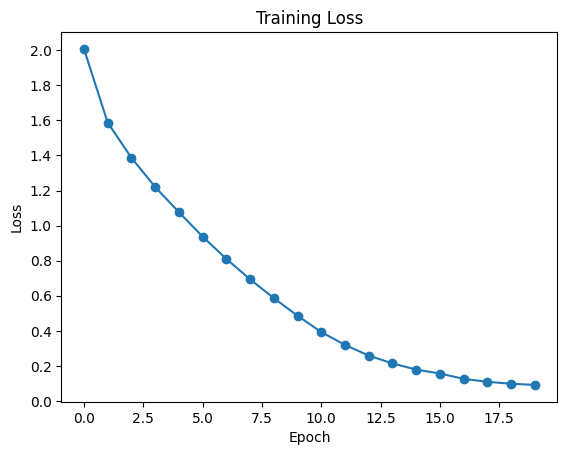

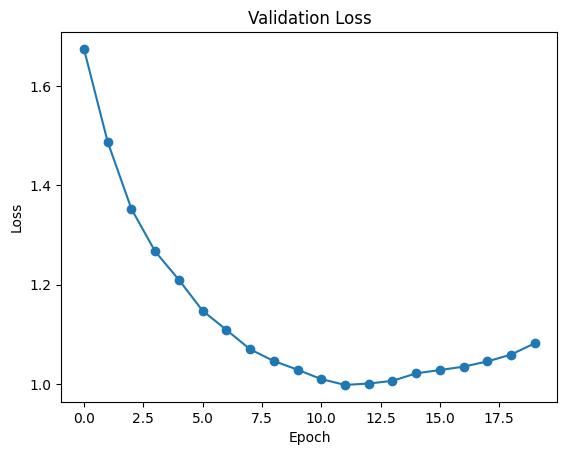

In [25]:
max_input_length = 5
how_many_marges = 1500 # maximum number of merges generation 

input_lang, output_lang, train_loader, val_loader, max_len = \
    get_train_val_dataloaders(batch_size=32,
                              lang1='eng', lang2='span',
                              max_length=max_input_length, valid_ratio=0.1,
                              num_merges=(how_many_marges, 'sp'))

hidden_size = 256

encoder = rnn_encoder(input_lang.n_words, hidden_size).to(device)
decoder = rnn_att_decoder(hidden_size, output_lang.n_words,
                          max_length=input_lang.max_len, n_heads=4, n_layers=2).to(device)

# Train with validation
train(train_loader, encoder, decoder,
      n_epochs=20, print_step=1, plot_step=1, valid_dataloader=val_loader)

In [26]:
import os

def save_models(encoder, decoder, save_dir="checkpoints"):
    os.makedirs(save_dir, exist_ok=True)

    torch.save(encoder.state_dict(), os.path.join(save_dir, "encoder_3.pt"))
    torch.save(decoder.state_dict(), os.path.join(save_dir, "decoder_3.pt"))

    print(f"Models saved to {save_dir}/")

save_models(encoder, decoder)

Models saved to checkpoints/


input = hi i run .
output = corre .


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:762: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:763: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


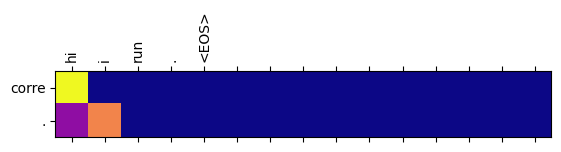

In [28]:
evaluate_and_show_attention("hi i run .", encoder, decoder, input_lang, output_lang)

input = is tom sick ?
output = tom está enfermo ?


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:762: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:763: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


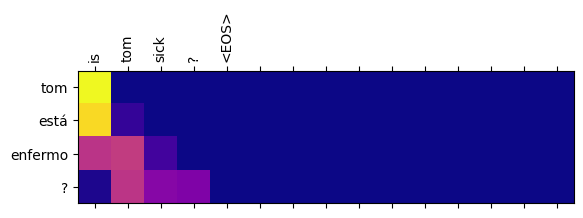

In [27]:
evaluate_and_show_attention("is tom sick ?", encoder, decoder, input_lang, output_lang)

input = aba ciuppa ciups .
output = andomediocmedioc faltatá recibió senciales .


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:762: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:763: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


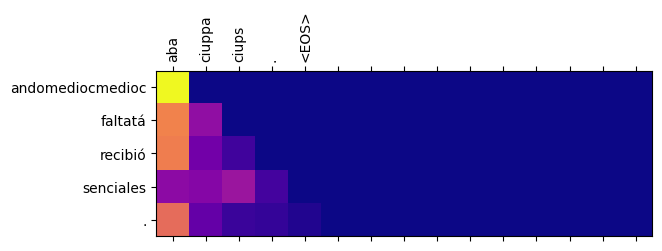

In [31]:
evaluate_and_show_attention("aba ciuppa ciups .", encoder, decoder, input_lang, output_lang)

input = is tom smiling ?
output = migoligenteligenteruinruinruinruinruinruinruinruinruin hemos hemos hemos


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:762: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:763: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


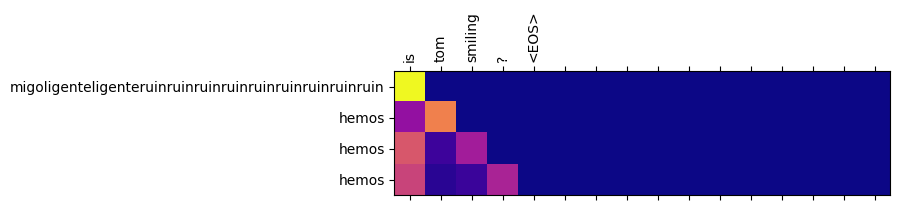

In [47]:
evaluate_and_show_attention("is tom smiling ?", encoder, decoder, input_lang, output_lang)

## eng-ita

In [5]:
max_input_length = 5
how_many_marges = 2500 # maximum number of merges generation 

input_lang, output_lang, train_loader, val_loader, max_len = \
    get_train_val_dataloaders(batch_size=32,
                              lang1='eng', lang2='ita',
                              max_length=max_input_length, valid_ratio=0.1,
                              num_merges=(how_many_marges, 'sp'))

400014 sentence pairs readed
reduced to 28287 sentence pairs
eng 3629
ita 7972


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /var/folders/r3/_0ks66091gjflcf_s930gfs00000gn/T/tmp9xpvbb81
  input_format: 
  model_prefix: /var/folders/r3/_0ks66091gjflcf_s930gfs00000gn/T/tmp9xpvbb81_spm
  model_type: BPE
  vocab_size: 2500
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 2
  bos_id: 0
  eos_id: 1
  pad_id: 3
  unk_piece: <unk>
  bos_piece: <s>
  

eng vocab size after SentencePiece: 2500
ita vocab size after SentencePiece: 2500


In [6]:
hidden_size = 256

encoder = rnn_encoder(input_lang.n_words, hidden_size).to(device)
decoder = rnn_att_decoder(hidden_size, output_lang.n_words,
                          max_length=input_lang.max_len, n_heads=4, n_layers=2).to(device)

# Train with validation
train(train_loader, encoder, decoder,
      n_epochs=20, print_step=1, plot_step=1, valid_dataloader=val_loader)

2 m 13 sec remaining: 42 m 23 sec (1 5%) train: 1.4415 val: 1.1520
4 m 48 sec remaining: 43 m 16 sec (2 10%) train: 1.0010 val: 0.9182
7 m 21 sec remaining: 41 m 39 sec (3 15%) train: 0.7434 val: 0.7308
9 m 59 sec remaining: 39 m 58 sec (4 20%) train: 0.5402 val: 0.6115
12 m 44 sec remaining: 38 m 13 sec (5 25%) train: 0.4112 val: 0.5429
15 m 54 sec remaining: 37 m 6 sec (6 30%) train: 0.3296 val: 0.5065
18 m 58 sec remaining: 35 m 14 sec (7 35%) train: 0.2774 val: 0.4886
22 m 5 sec remaining: 33 m 8 sec (8 40%) train: 0.2426 val: 0.4771
25 m 0 sec remaining: 30 m 33 sec (9 45%) train: 0.2193 val: 0.4759
27 m 40 sec remaining: 27 m 40 sec (10 50%) train: 0.2021 val: 0.4682
30 m 32 sec remaining: 24 m 59 sec (11 55%) train: 0.1918 val: 0.4697
33 m 13 sec remaining: 22 m 9 sec (12 60%) train: 0.1830 val: 0.4794
35 m 39 sec remaining: 19 m 12 sec (13 65%) train: 0.1763 val: 0.4785
37 m 55 sec remaining: 16 m 15 sec (14 70%) train: 0.1737 val: 0.4822
40 m 15 sec remaining: 13 m 25 sec (15 

/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [7]:
import os

def save_models(encoder, decoder, save_dir="checkpoints"):
    os.makedirs(save_dir, exist_ok=True)

    torch.save(encoder.state_dict(), os.path.join(save_dir, "encoder_ita.pt"))
    torch.save(decoder.state_dict(), os.path.join(save_dir, "decoder_ita.pt"))

    print(f"Models saved to {save_dir}/")

save_models(encoder, decoder)

Models saved to checkpoints/


input = hi .
output = ciao !


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:762: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:763: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


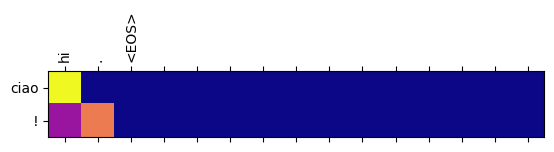

In [11]:
evaluate_and_show_attention("hi .", encoder, decoder, input_lang, output_lang)

input = skibidiboppi
output = coiascono .


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:762: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq_eval.py:763: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


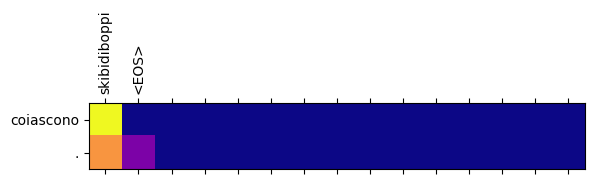

In [34]:
evaluate_and_show_attention("skibidiboppi", encoder, decoder, input_lang, output_lang)

## eng-arab

In [4]:
input_lang, output_lang, pairs = read_pair('eng', 'arab', max_length=8)
print(random.choice(pairs))

12569 sentence pairs readed
reduced to 7966 sentence pairs
eng 3073
arab 7162
['you hate tourists don t you ?', 'انت تكره السياح أليس كذلك']


In [8]:
input_lang, output_lang, train_dataloader = get_dataloader(batch_size, 'eng', 'arab', max_length=8)

encoder = rnn_encoder(input_lang.n_words, hidden_size).to(device)
decoder = rnn_att_decoder(hidden_size, output_lang.n_words, Luong=False, max_length=8).to(device)

train(train_dataloader, encoder, decoder, 250, print_step=5, plot_step=2)

12569 sentence pairs readed
reduced to 7966 sentence pairs
eng 3073
arab 7162
0 m 32 sec remaining: 26 m 34 sec (5 2%) 3.7205
0 m 59 sec remaining: 23 m 51 sec (10 4%) 2.9723
1 m 25 sec remaining: 22 m 25 sec (15 6%) 2.6281
1 m 53 sec remaining: 21 m 43 sec (20 8%) 2.3390
2 m 22 sec remaining: 21 m 22 sec (25 10%) 2.0960
2 m 50 sec remaining: 20 m 46 sec (30 12%) 1.8899
3 m 19 sec remaining: 20 m 27 sec (35 14%) 1.7139
3 m 50 sec remaining: 20 m 9 sec (40 16%) 1.5649
4 m 17 sec remaining: 19 m 34 sec (45 18%) 1.4379
4 m 45 sec remaining: 19 m 2 sec (50 20%) 1.3296
5 m 14 sec remaining: 18 m 35 sec (55 22%) 1.2370
5 m 42 sec remaining: 18 m 3 sec (60 24%) 1.1576
6 m 11 sec remaining: 17 m 36 sec (65 26%) 1.0865
6 m 38 sec remaining: 17 m 5 sec (70 28%) 1.0254
7 m 6 sec remaining: 16 m 35 sec (75 30%) 0.9709
7 m 35 sec remaining: 16 m 8 sec (80 32%) 0.9236
8 m 3 sec remaining: 15 m 39 sec (85 34%) 0.8795
8 m 29 sec remaining: 15 m 5 sec (90 36%) 0.8387
8 m 55 sec remaining: 14 m 34 sec (

/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [12]:
encoder.eval()
decoder.eval()
evaluate_random(encoder, decoder, pairs, input_lang, output_lang, n=5)

input: where is your school ?
correct: أين مدرستك
output: أين ستكون كثيرا <EOS>

input: i can come tomorrow .
correct: بإمكاني القدوم غدا .
output: بالكاد أسمعك . <EOS>

input: i bought her a watch .
correct: اشتريت لها ساعة .
output: اشتريت لها على تقريرك . <EOS>

input: he is not japanese .
correct: هو ليس يابانيا .
output: هو ليس يابانيا . <EOS>

input: tom sighed deeply .
correct: توم تنهد بعمق
output: هاجم توم تأكل ا <EOS>



input = what s tom doing now ?
output = ماذا يفعل الآن توم توم <EOS>


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq.py:529: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq.py:530: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis


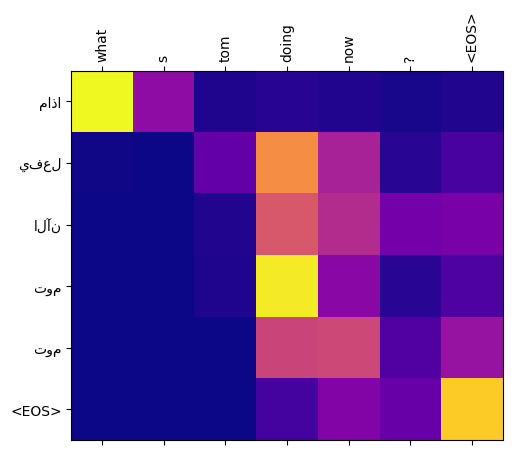

In [28]:
evaluate_and_show_attention(random.choice(pairs)[0], encoder, decoder, input_lang, output_lang)

## eng-npi

In [34]:
input_lang, output_lang, pairs = read_pair('eng', 'npi', max_length=32)
print(random.choice(pairs))

2823 sentence pairs readed
reduced to 2816 sentence pairs
eng 1994
npi 732
['tom likes to show off .', 'टमल ई द ख वट गर न मनपर छ']


2823 sentence pairs readed
reduced to 2816 sentence pairs
eng 1994
npi 732
0 m 27 sec remaining: 18 m 7 sec (5 2%) 2.0935
0 m 55 sec remaining: 17 m 29 sec (10 5%) 1.4045
1 m 23 sec remaining: 17 m 6 sec (15 7%) 1.2991
1 m 51 sec remaining: 16 m 45 sec (20 10%) 1.2238
2 m 19 sec remaining: 16 m 17 sec (25 12%) 1.1649
2 m 46 sec remaining: 15 m 45 sec (30 15%) 1.1165
3 m 15 sec remaining: 15 m 20 sec (35 17%) 1.0730
3 m 43 sec remaining: 14 m 54 sec (40 20%) 1.0346
4 m 12 sec remaining: 14 m 28 sec (45 22%) 1.0018
4 m 42 sec remaining: 14 m 6 sec (50 25%) 0.9723
5 m 12 sec remaining: 13 m 44 sec (55 27%) 0.9458
5 m 42 sec remaining: 13 m 20 sec (60 30%) 0.9226
6 m 11 sec remaining: 12 m 52 sec (65 32%) 0.9011
6 m 39 sec remaining: 12 m 22 sec (70 35%) 0.8812
7 m 8 sec remaining: 11 m 53 sec (75 37%) 0.8635
7 m 35 sec remaining: 11 m 23 sec (80 40%) 0.8465
8 m 2 sec remaining: 10 m 52 sec (85 42%) 0.8306
8 m 30 sec remaining: 10 m 24 sec (90 45%) 0.8164
8 m 58 sec remaining: 9 m 55 sec (

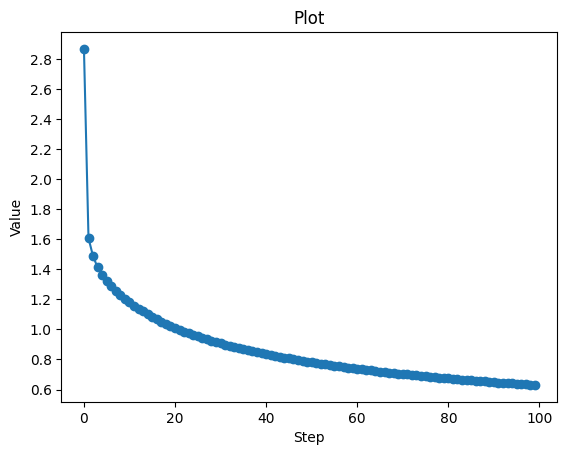

In [ ]:
input_lang, output_lang, train_dataloader = get_dataloader(batch_size, 'eng', 'npi', max_length=32)

encoder = rnn_encoder(input_lang.n_words, hidden_size).to(device)
decoder = rnn_att_decoder(hidden_size, output_lang.n_words, Luong=False, max_length=32).to(device)

train(train_dataloader, encoder, decoder, 300, print_step=5, plot_step=2)

In [42]:
encoder.eval()
decoder.eval()
evaluate_random(encoder, decoder, pairs, input_lang, output_lang, n=5)

input: can you talk about that a little ?
correct: यसब र अल कत क र गर न सक न ह न छ ?
output: भर खर खर स मब र गएक छ ऊ ग ग क ? <EOS>

input: my mother is two years younger than my father .
correct: म र आम ब ब भन द द ई वर ष क न छ ह न ह न छ
output: म र म त र म त र म त छ क ह न ह न छ ? <EOS>

input: tom abused mary .
correct: टमल म र ल ई द र व यवह र गर
output: टमल त यस गर न आवश यक धन यव यमस ग ई मद दत गर क ? <EOS>

input: tom knew i was tired .
correct: टमल ई म थ क क थ ह थ य
output: टमल म न म ल य क छ <EOS>

input: you don t need to finish it by tomorrow .
correct: तप ई ल यसल ई भ ल सम म प र गर न आवश यक छ न
output: क घन ट ट त म ल कह ल सम क षर घट उन पर छ ? <EOS>



input = did you see tom steal it ?
output = टमस ग सम झन न ल ई सम झन न टमल ई सम ? <EOS>


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq.py:529: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + in_prhase.split(' ') + ['<EOS>'], rotation=90)  # Input words on x-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq.py:530: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + out_w)  # Output words on y-axis
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2335 (\N{DEVANAGARI LETTER TTA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari

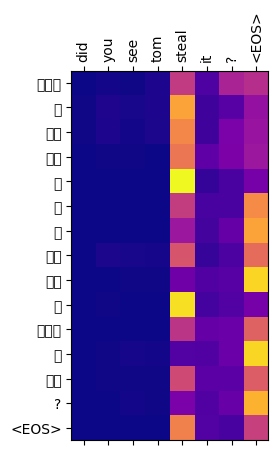

In [38]:
evaluate_and_show_attention('did you see tom steal it ?', encoder, decoder, input_lang, output_lang)

## chat-response

In [43]:
input_lang, output_lang, pairs = read_pair('chat', 'response', max_length=10)
print(random.choice(pairs))

3725 sentence pairs readed
reduced to 2103 sentence pairs
chat 1580
response 1581
['that isn t a good deal ?', 'a good gun costs or more .']


3725 sentence pairs readed
reduced to 2103 sentence pairs
chat 1580
response 1581
0 m 7 sec remaining: 19 m 32 sec (5 0%) 4.1459
0 m 14 sec remaining: 19 m 10 sec (10 1%) 3.1790
0 m 22 sec remaining: 19 m 14 sec (15 1%) 2.9617
0 m 29 sec remaining: 19 m 11 sec (20 2%) 2.7786
0 m 36 sec remaining: 19 m 5 sec (25 3%) 2.6132
0 m 43 sec remaining: 18 m 46 sec (30 3%) 2.4702
0 m 51 sec remaining: 18 m 50 sec (35 4%) 2.3408
0 m 59 sec remaining: 18 m 50 sec (40 5%) 2.2250
1 m 7 sec remaining: 18 m 49 sec (45 5%) 2.1161
1 m 15 sec remaining: 18 m 45 sec (50 6%) 2.0171
1 m 22 sec remaining: 18 m 42 sec (55 6%) 1.9288
1 m 30 sec remaining: 18 m 39 sec (60 7%) 1.8457
1 m 38 sec remaining: 18 m 34 sec (65 8%) 1.7700
1 m 46 sec remaining: 18 m 26 sec (70 8%) 1.6984
1 m 53 sec remaining: 18 m 13 sec (75 9%) 1.6329
1 m 59 sec remaining: 17 m 58 sec (80 10%) 1.5751
2 m 6 sec remaining: 17 m 45 sec (85 10%) 1.5158
2 m 14 sec remaining: 17 m 38 sec (90 11%) 1.4644
2 m 21 sec remaining: 17 m 29 sec (95 

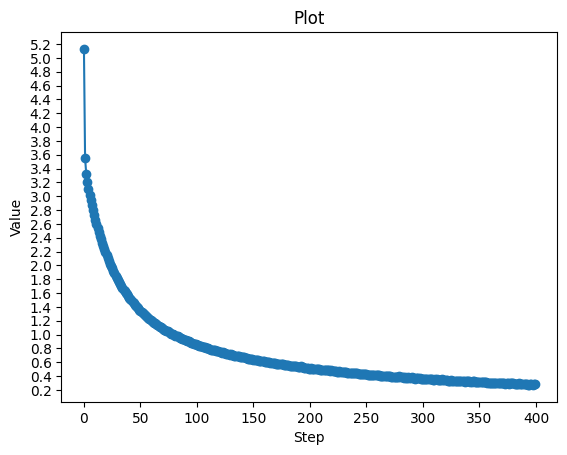

In [48]:
input_lang, output_lang, train_dataloader = get_dataloader(batch_size, 'chat', 'response', max_length=10)

encoder = rnn_encoder(input_lang.n_words, hidden_size).to(device)
decoder = rnn_att_decoder(hidden_size, output_lang.n_words, Luong=False, max_length=10).to(device)

train(train_dataloader, encoder, decoder, 800, print_step=5, plot_step=2)

In [49]:
encoder.eval()
decoder.eval()
evaluate_random(encoder, decoder, pairs, input_lang, output_lang, n=5)

input: where did you go ?
correct: we went to a nice restaurant .
output: i ve like to have stripes . <EOS>

input: i wish i could move here .
correct: maybe you can if someone moves out .
output: what did you say that ? <EOS>

input: i don t know .
correct: when did you lose it ?
output: i ll bet i grow up to one dollar .

input: yes they are .
correct: the streets and sidewalks are clean .
output: and the streets and sidewalks are clean . <EOS>

input: what kind of dressing do you use ?
correct: i pour lots of french dressing on top .
output: this is there a world and window . <EOS>



input = i tell my students to become a teacher .
output = teaching is a great job . <EOS>


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq.py:529: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq.py:530: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  # Set up axes labels


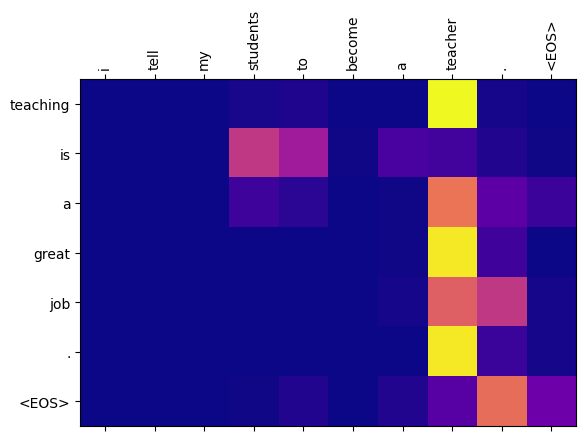

In [60]:
evaluate_and_show_attention(random.choice(pairs)[0], encoder, decoder, input_lang, output_lang)

### logic-solution

In [61]:
input_lang, output_lang, pairs = read_pair('logic', 'solution', max_length=14)

850 sentence pairs readed
reduced to 850 sentence pairs
logic 15
solution 11


In [62]:
print(random.choice(pairs))

['0 AND 1 OR NOT 0 AND 0', '0']


850 sentence pairs readed
reduced to 850 sentence pairs
logic 15
solution 11
0 m 3 sec remaining: 0 m 47 sec (5 6%) 0.5173
0 m 6 sec remaining: 0 m 45 sec (10 12%) 0.1622
0 m 9 sec remaining: 0 m 41 sec (15 18%) 0.1224
0 m 12 sec remaining: 0 m 38 sec (20 25%) 0.1102
0 m 16 sec remaining: 0 m 35 sec (25 31%) 0.0985
0 m 19 sec remaining: 0 m 32 sec (30 37%) 0.0773
0 m 22 sec remaining: 0 m 29 sec (35 43%) 0.0570
0 m 26 sec remaining: 0 m 26 sec (40 50%) 0.0452
0 m 29 sec remaining: 0 m 22 sec (45 56%) 0.0372
0 m 32 sec remaining: 0 m 19 sec (50 62%) 0.0321
0 m 35 sec remaining: 0 m 16 sec (55 68%) 0.0293
0 m 38 sec remaining: 0 m 12 sec (60 75%) 0.0244
0 m 42 sec remaining: 0 m 9 sec (65 81%) 0.0168
0 m 45 sec remaining: 0 m 6 sec (70 87%) 0.0141
0 m 48 sec remaining: 0 m 3 sec (75 93%) 0.0092
0 m 51 sec remaining: 0 m 0 sec (80 100%) 0.0088


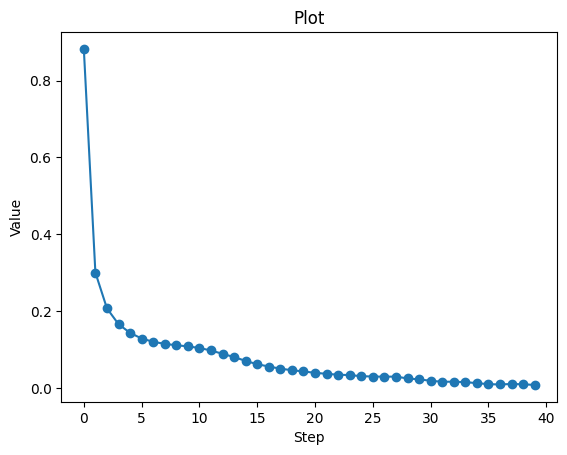

In [70]:
input_lang, output_lang, train_dataloader = get_dataloader(batch_size, 'logic', 'solution', max_length=14)

encoder = rnn_encoder(input_lang.n_words, hidden_size).to(device)
decoder = rnn_att_decoder(hidden_size, output_lang.n_words, Luong=False, max_length=14).to(device)

train(train_dataloader, encoder, decoder, 80, print_step=5, plot_step=2)

In [71]:
encoder.eval()
decoder.eval()
evaluate_random(encoder, decoder, pairs, input_lang, output_lang, n=5)

input: e > b ; b > f ; f > a ; e
correct: a
output: a <EOS>

input: e > d ; d > c ; c > a ; e
correct: a
output: a <EOS>

input: b > a ; a > e ; e > c ; b
correct: c
output: c <EOS>

input: 0 AND 1 OR NOT 1 AND NOT 0
correct: 0
output: 0 <EOS>

input: c > a ; c
correct: a
output: d <EOS>



input = 1 AND 1 OR NOT 1 AND NOT 1
output = 1 <EOS>


/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq.py:529: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  
/Users/leonardoangellotti/Desktop/universita/NLP/esame_2/seq2seq.py:530: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  # Set up axes labels


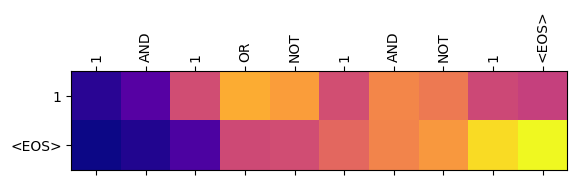

In [72]:
evaluate_and_show_attention('1 AND 1 OR NOT 1 AND NOT 1', encoder, decoder, input_lang, output_lang)

### Analising datasets

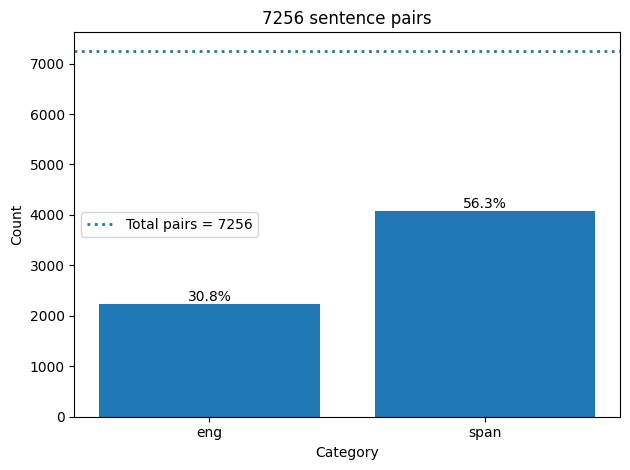

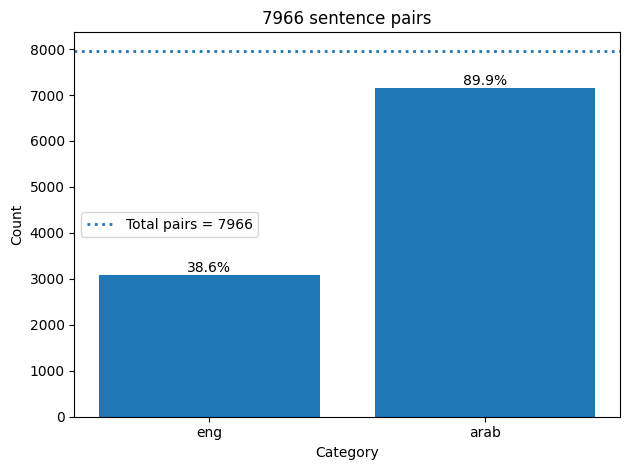

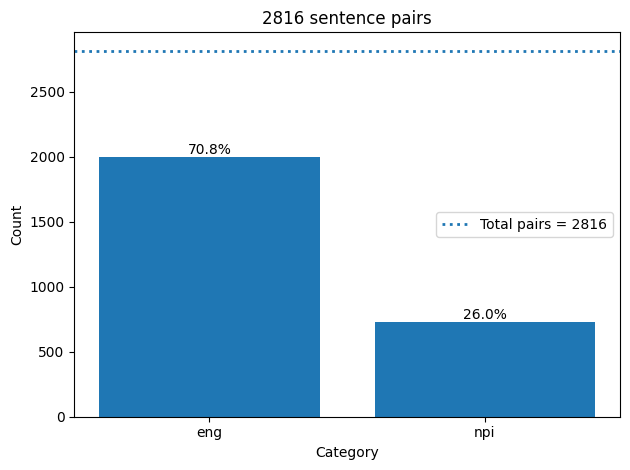

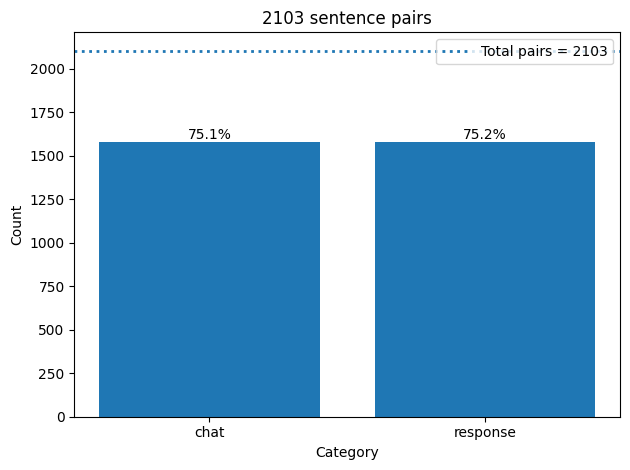

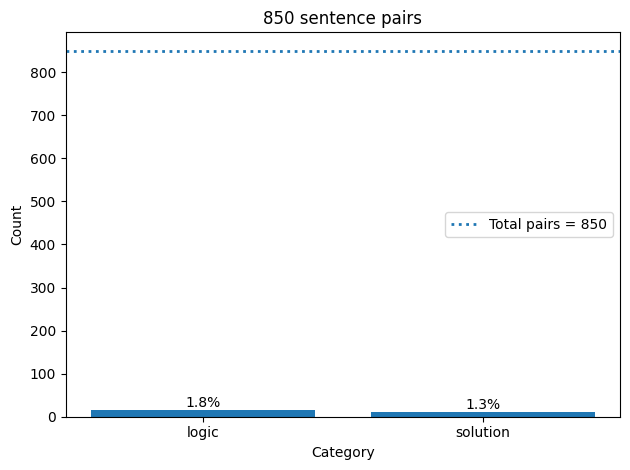

In [3]:
import matplotlib.pyplot as plt

# Data sets with total sentence pairs
datasets = [
    (7256, {"eng": 2235, "span": 4082}),
    (7966, {"eng": 3073, "arab": 7162}),
    (2816, {"eng": 1994, "npi": 732}),
    (2103, {"chat": 1580, "response": 1581}),
    (850, {"logic": 15, "solution": 11}),
]

for total_pairs, data in datasets:
    plt.figure()

    categories = list(data.keys())
    values = list(data.values())

    bars = plt.bar(categories, values)

    # Dotted line for total number of sentence pairs
    plt.axhline(
        y=total_pairs,
        linestyle=":",
        linewidth=2,
        label=f"Total pairs = {total_pairs}"
    )

    # Percentage labels above each bar
    for bar, value in zip(bars, values):
        percentage = (value / total_pairs) * 100
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{percentage:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.title(f"{total_pairs} sentence pairs")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()
